# Exploratory Data Analysis of Retinal OCT Images for Disease Classification

This notebook presents the initial exploratory analysis of the **Kermany2018 Retinal OCT Images** dataset, which contains optical coherence tomography (OCT) images classified into four categories: **CNV, DME, DRUSEN, and NORMAL**.

The main goal of this notebook is to understand the dataset structure before training deep learning models. The analysis includes verifying the available data splits, counting the number of images per class, identifying class imbalance, visualizing sample images, and generating basic plots that will support the experimental methodology of the final project.

This exploration is an essential first step because the dataset is imbalanced: some retinal conditions contain substantially fewer images than others. Therefore, the project will not rely only on overall accuracy, but will also consider metrics such as **precision, recall, F1-score, and Macro F1-score** to evaluate model performance more fairly across all classes.

In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
INPUT_DIR = "/kaggle/input"

print("Contenido de /kaggle/input:")
for item in os.listdir(INPUT_DIR):
    print("-", item)

Contenido de /kaggle/input:
- datasets


In [6]:
for root, dirs, files in os.walk("/kaggle/input/datasets"):
    level = root.replace("/kaggle/input/datasets", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    
    for d in dirs[:10]:
        print(f"{indent}    {d}/")
    
    if level >= 4:
        break

datasets/
    fabrizioravelli/
    fabrizioravelli/
        retinal-oct-images-splitted/
        retinal-oct-images-splitted/
            training/
            test/
            training/
                val/
                train/
                val/
                    DRUSEN/
                    CNV/
                    NORMAL/
                    DME/


In [7]:
DATA_DIR = "/kaggle/input/datasets/fabrizioravelli/retinal-oct-images-splitted"

train_dir = os.path.join(DATA_DIR, "training", "train")
val_dir = os.path.join(DATA_DIR, "training", "val")
test_dir = os.path.join(DATA_DIR, "test")

print("Train existe:", os.path.exists(train_dir), train_dir)
print("Val existe:", os.path.exists(val_dir), val_dir)
print("Test existe:", os.path.exists(test_dir), test_dir)

print("\nClases en train:")
print(os.listdir(train_dir))

print("\nClases en val:")
print(os.listdir(val_dir))

print("\nClases en test:")
print(os.listdir(test_dir))

Train existe: True /kaggle/input/datasets/fabrizioravelli/retinal-oct-images-splitted/training/train
Val existe: True /kaggle/input/datasets/fabrizioravelli/retinal-oct-images-splitted/training/val
Test existe: True /kaggle/input/datasets/fabrizioravelli/retinal-oct-images-splitted/test

Clases en train:
['DRUSEN', 'CNV', 'NORMAL', 'DME']

Clases en val:
['DRUSEN', 'CNV', 'NORMAL', 'DME']

Clases en test:
['DRUSEN', 'CNV', 'NORMAL', 'DME']


In [8]:
import pandas as pd

def count_images_by_class(folder, split_name):
    data = []
    
    for class_name in sorted(os.listdir(folder)):
        class_path = os.path.join(folder, class_name)
        
        if os.path.isdir(class_path):
            image_files = [
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
            
            data.append({
                "split": split_name,
                "class": class_name,
                "count": len(image_files)
            })
    
    return data


counts = []
counts.extend(count_images_by_class(train_dir, "train"))
counts.extend(count_images_by_class(val_dir, "val"))
counts.extend(count_images_by_class(test_dir, "test"))

df_counts = pd.DataFrame(counts)
df_counts

,split,class,count
0,train,CNV,25310
1,train,DME,8788
2,train,DRUSEN,6256
3,train,NORMAL,20930
4,val,CNV,3163
5,val,DME,1098
6,val,DRUSEN,782
7,val,NORMAL,2616
8,test,CNV,3165
9,test,DME,1099


In [13]:
df_pivot = df_counts.pivot(index="class", columns="split", values="count")
df_pivot["total"] = df_pivot.sum(axis=1)
df_pivot["percentage"] = (df_pivot["total"] / df_pivot["total"].sum()) * 100
df_pivot = df_pivot.sort_values("total", ascending=False)

df_pivot

split,test,train,val,total,percentage
class,,,,,
CNV,3165,25310,3163,31638,41.299098
NORMAL,2617,20930,2616,26163,34.152232
DME,1099,8788,1098,10985,14.339421
DRUSEN,783,6256,782,7821,10.209250


In [10]:
total_images = df_pivot["total"].sum()
print("Total de imágenes:", total_images)

Total de imágenes: 76607


In [15]:
df_pivot.to_csv("01_resumen_dataset_kermany2018.csv")

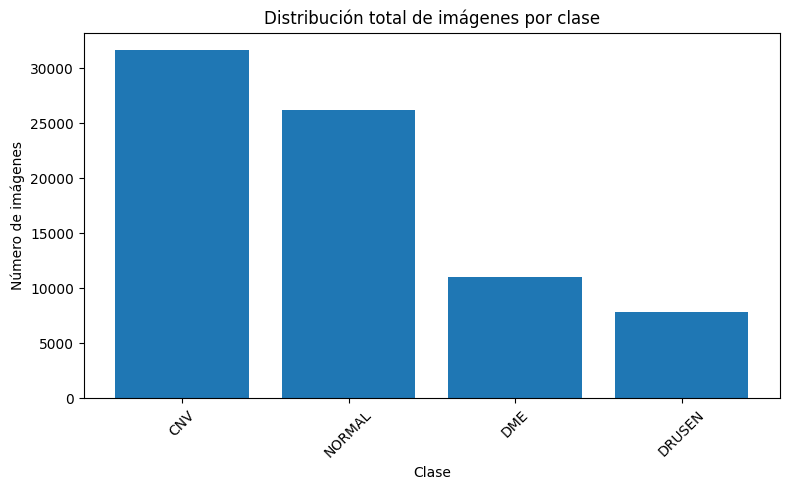

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(df_pivot.index, df_pivot["total"])
plt.title("Distribución total de imágenes por clase")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("01_distribucion_total_clases.png", dpi=300)
plt.show()

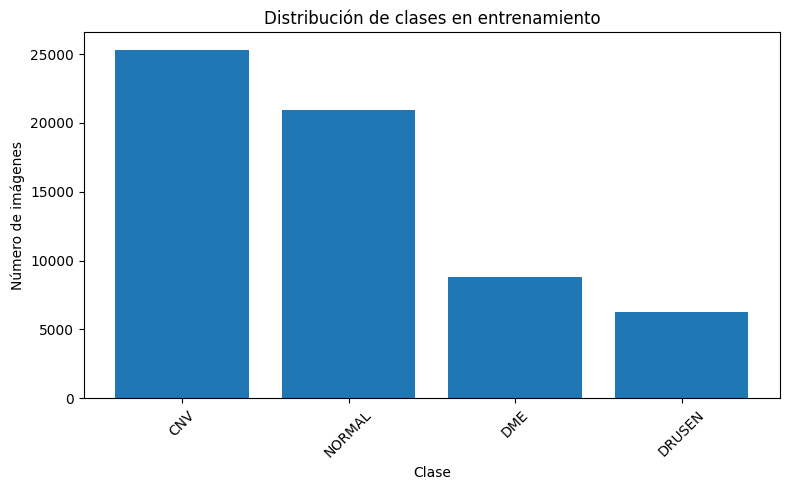

In [16]:
train_counts = df_counts[df_counts["split"] == "train"].copy()
train_counts = train_counts.sort_values("count", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(train_counts["class"], train_counts["count"])
plt.title("Distribución de clases en entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("02_distribucion_train_clases.png", dpi=300)
plt.show()

## Examples per class

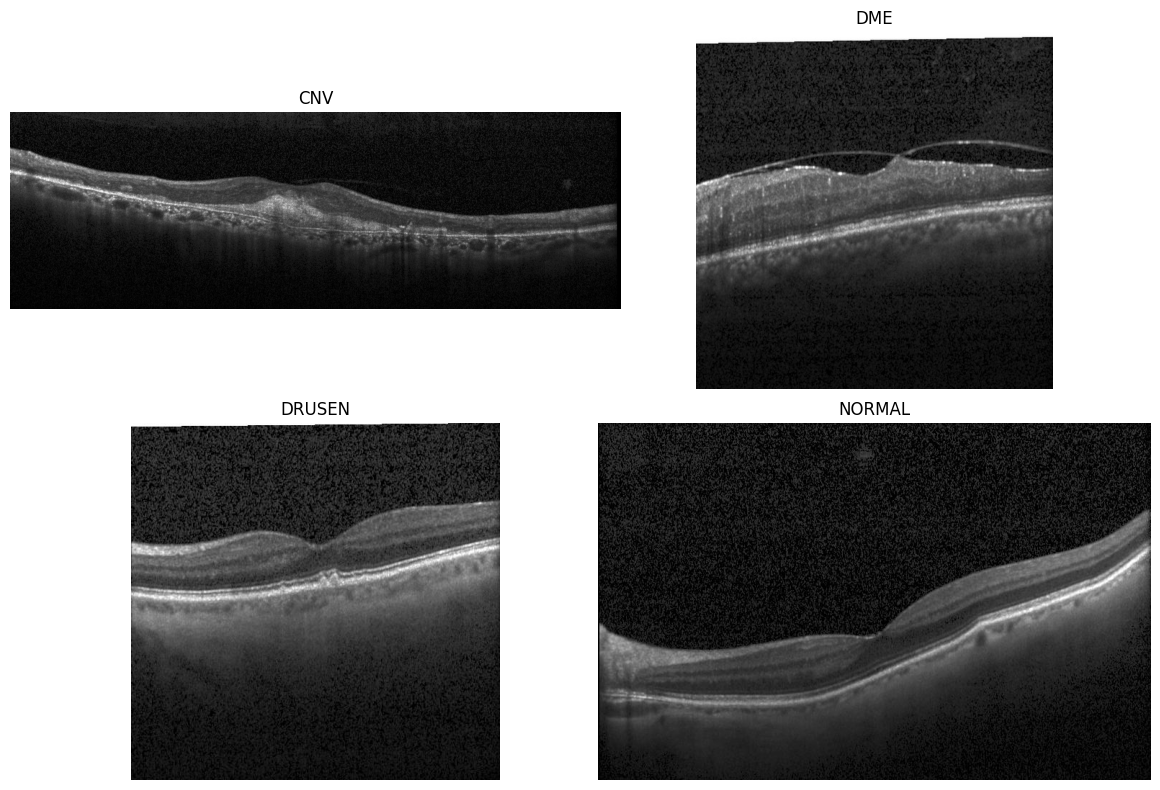

In [12]:
import random
from PIL import Image
import matplotlib.pyplot as plt

classes = sorted(os.listdir(train_dir))

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)
    
    img = Image.open(image_path)
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.savefig("02_ejemplos_por_clase.png", dpi=300)
plt.show()